In [26]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
renecardoso_housing_prices_in_cdmx_path = kagglehub.dataset_download('renecardoso/housing-prices-in-cdmx')

print('Data source import complete.')


Data source import complete.


In [27]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/housing-prices-in-cdmx/housing_data_CDMX.csv
/kaggle/input/housing-prices-in-cdmx/housing_data_CDMX_v2.csv


In [28]:
df = pd.read_csv('/kaggle/input/housing-prices-in-cdmx/housing_data_CDMX_v2.csv')
df.head()

,property_type,places,lat-lon,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,lat,lon
0,apartment,MiguelHidalgo,"23.634501,-102.552788",5500000.0,MXN,5450245.50,289775.66,54.0,54.0,5366.215926,101851.85190,23.634501,-102.552788
1,house,Iztapalapa,"19.31033,-99.068557",1512000.0,MXN,1498321.97,79661.96,80.0,80.0,995.774500,18900.00000,19.310330,-99.068557
2,apartment,Tlalpan,"19.279771,-99.234597",926667.0,MXN,918284.00,48822.82,100.0,100.0,488.228200,9266.67000,19.279771,-99.234597
3,apartment,MiguelHidalgo,"23.634501,-102.552788",6410000.0,MXN,6352013.39,337720.36,135.0,135.0,2501.632296,47481.48148,23.634501,-102.552788
4,apartment,MiguelHidalgo,"19.432657,-99.177444",4416000.0,MXN,4376051.62,232663.51,87.0,87.0,2674.293218,50758.62069,19.432657,-99.177444


In [29]:
df.isnull().sum()

,0
property_type,0
places,0
lat-lon,0
price,0
currency,0
price_aprox_local_currency,0
price_aprox_usd,0
surface_total_in_m2,0
surface_covered_in_m2,0
price_usd_per_m2,0


In [30]:
df.drop_duplicates(inplace=True)

In [31]:
df.drop(columns=['lat-lon'], inplace=True)

In [32]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

X = df.drop(columns=['price_aprox_usd'], axis=1)
y = df.price_aprox_usd

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
from sklearn.cluster import KMeans

n_clusters = 2
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
kmeans.fit(X_train[['lat', 'lon']])
X_train['zona_cluster'] = kmeans.predict(X_train[['lat', 'lon']]) +1
X_test['zona_cluster'] = kmeans.predict(X_test[['lat', 'lon']]) +1

In [34]:
X_train

,property_type,places,price,currency,price_aprox_local_currency,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,lat,lon,zona_cluster
4440,apartment,BenitoJuarez,1902000.0,MXN,1884793.95,65.0,65.0,1541.687538,29261.538460,19.369777,-99.137803,1
4502,apartment,MiguelHidalgo,7950000.0,MXN,7878082.04,127.0,127.0,3298.090866,62598.425200,19.443178,-99.202370,1
5494,apartment,Iztapalapa,636500.0,MXN,630741.91,50.0,50.0,670.698800,12730.000000,19.332034,-99.062028,1
15724,house,Coyoacan,4800000.0,MXN,4757705.81,180.0,234.0,1405.306056,20512.820510,19.350214,-99.162146,1
12156,house,Tlalpan,1750000.0,MXN,1734168.90,302.0,302.0,305.302450,5794.701987,19.290401,-99.143196,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5766,apartment,GustavoAMadero,1210963.0,MXN,1200292.82,75.0,75.0,850.886800,16146.173330,19.466238,-99.108478,1
15827,house,Cuajimalpa,15000000.0,MXN,14867830.91,1700.0,100.0,464.990982,150000.000000,19.355751,-99.299350,1
6007,apartment,AlvaroObregon,761172.0,MXN,754286.11,70.0,70.0,572.906714,10873.885710,19.366632,-99.197900,1
882,apartment,BenitoJuarez,2856500.0,MXN,2830659.31,96.0,96.0,1567.697292,29755.208330,19.373306,-99.146919,1


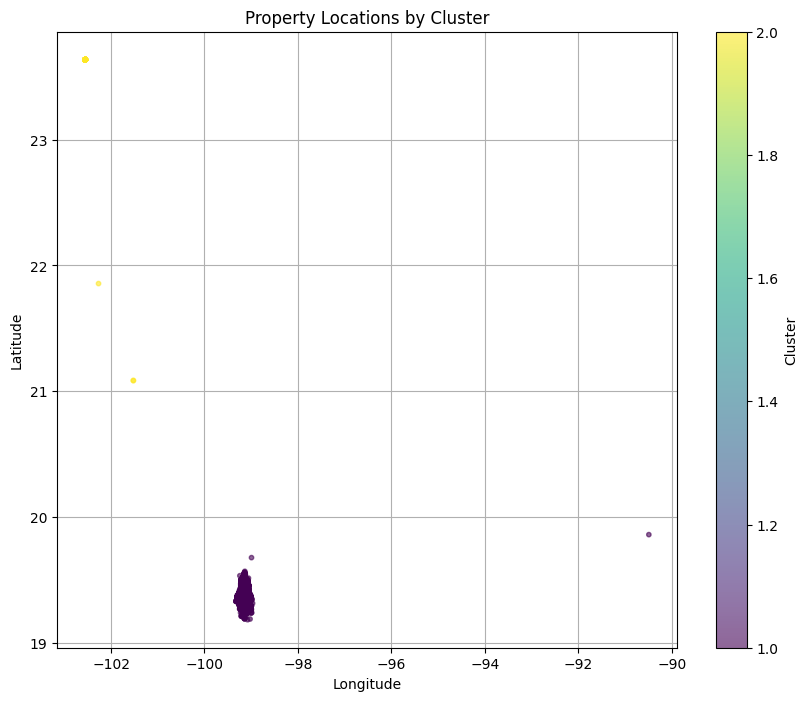

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_train['lon'], X_train['lat'], c=X_train['zona_cluster'], cmap='viridis', s=10, alpha=0.6)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Property Locations by Cluster')
plt.colorbar(scatter, label='Cluster')
plt.grid(True)
plt.show()

In [36]:
X_train.zona_cluster.value_counts()

,count
zona_cluster,
1,12069
2,155


In [37]:
X_train['lat_rad'] = np.deg2rad(X_train['lat'])
X_train['lon_rad'] = np.deg2rad(X_train['lon'])

X_train['x_coord'] = np.cos(X_train['lat_rad']) * np.cos(X_train['lon_rad'])
X_train['y_coord'] = np.cos(X_train['lat_rad']) * np.sin(X_train['lon_rad'])
X_train['z_coord'] = np.sin(X_train['lat_rad'])

In [38]:
X_test['lat_rad'] = np.deg2rad(X_test['lat'])
X_test['lon_rad'] = np.deg2rad(X_test['lon'])

X_test['x_coord'] = np.cos(X_test['lat_rad']) * np.cos(X_test['lon_rad'])
X_test['y_coord'] = np.cos(X_test['lat_rad']) * np.sin(X_test['lon_rad'])
X_test['z_coord'] = np.sin(X_test['lat_rad'])

In [39]:
X_drop = X_train.drop(columns=['lat', 'lon', 'lat_rad', 'lon_rad'], inplace=True)
X_test_drop = X_test.drop(columns=['lat', 'lon', 'lat_rad', 'lon_rad'], inplace=True)

In [40]:
X_train.head()

,property_type,places,price,currency,price_aprox_local_currency,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,zona_cluster,x_coord,y_coord,z_coord
4440,apartment,BenitoJuarez,1902000.0,MXN,1884793.95,65.0,65.0,1541.687538,29261.538460,1,-0.149821,-0.931425,0.331664
4502,apartment,MiguelHidalgo,7950000.0,MXN,7878082.04,127.0,127.0,3298.090866,62598.425200,1,-0.150802,-0.930836,0.332872
5494,apartment,Iztapalapa,636500.0,MXN,630741.91,50.0,50.0,670.698800,12730.000000,1,-0.148623,-0.931838,0.331042
15724,house,Coyoacan,4800000.0,MXN,4757705.81,180.0,234.0,1405.306056,20512.820510,1,-0.150234,-0.931473,0.331341
12156,house,Tlalpan,1750000.0,MXN,1734168.90,302.0,302.0,305.302450,5794.701987,1,-0.149981,-0.931864,0.330356


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [42]:
X_train.select_dtypes(include=['object']).columns, X_train.select_dtypes(exclude=['object']).columns

(Index(['property_type', 'places', 'currency'], dtype='object'),
 Index(['price', 'price_aprox_local_currency', 'surface_total_in_m2',
        'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2',
        'zona_cluster', 'x_coord', 'y_coord', 'z_coord'],
       dtype='object'))

In [43]:
num_pipe = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('onehot', OneHotEncoder())
])

col_tr = ColumnTransformer([
    ('num', num_pipe, ['price', 'price_aprox_local_currency', 'surface_total_in_m2',
        'surface_covered_in_m2', 'price_usd_per_m2', 'price_per_m2', 'x_coord', 'y_coord', 'z_coord'])
    ,
    ('cat', cat_pipe, ['property_type', 'places', 'currency', 'zona_cluster'])
])
pipeline = Pipeline([
    ('col_tr', col_tr),
    ('model', XGBRegressor(random_state=42))
])

In [44]:
from scipy.stats import randint, loguniform

params = {
    'model__learning_rate': loguniform(0.001, 0.1),
    'model__n_estimators': randint(100, 1001),
    'model__max_depth': randint(3,11),
    'model__subsample': loguniform(0.3, 1.0),
    'model__colsample_bytree': loguniform(0.3, 0.8),
    'model__gamma': loguniform(0.01, 1)
}

In [45]:
model = RandomizedSearchCV(pipeline, param_distributions=params, n_iter=100, cv=5, scoring='r2', n_jobs=-1, verbose=1, random_state=42)
model.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('col_tr',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('scaler',
                                                                                                StandardScaler())]),
                                                                               ['price',
                                                                                'price_aprox_local_currency',
                                                                                'surface_total_in_m2',
                                                                                'surface_covered_in_m2',
                                                                                'price_usd_per_m2',
                                                                                'price_per_m2',
                                                                                'x_coord',
                                                                                'y_coord',
                                                                                'z_coord']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('onehot',
                                                                                                OneHotEncoder())]),
                                                                               ['p...
                                        'model__learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cdca9d68690>,
                                        'model__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cdca9d9d910>,
                                        'model__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7cdcc034ed90>,
                                        'model__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7cdcc03be150>},
                   random_state=42, scoring='r2', verbose=1)

In [46]:
model.score(X_train, y_train), model.score(X_test, y_test)

(0.9973304097363214, 0.9963883615195971)